In [18]:
import os
import gzip
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import requests

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

In [19]:
URLS = {
    "title": "https://snap.stanford.edu/data/soc-redditHyperlinks-title.tsv",
    "body": "https://snap.stanford.edu/data/soc-redditHyperlinks-body.tsv",
}

for name, url in URLS.items():
    path = DATA_DIR / f"soc-redditHyperlinks-{name}.tsv"
    if path.exists():
        print(f"{path.name} already downloaded ({path.stat().st_size / 1e6:.1f} MB)")
        continue
    print(f"Downloading {name}...")
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"  Saved to {path} ({path.stat().st_size / 1e6:.1f} MB)")

  Saved to data/soc-redditHyperlinks-title.tsv (368.6 MB)
  Saved to data/soc-redditHyperlinks-body.tsv (318.9 MB)


In [20]:
title_path = DATA_DIR / "soc-redditHyperlinks-title.tsv"
body_path = DATA_DIR / "soc-redditHyperlinks-body.tsv"

# peek at first few lines + header
with open(title_path, encoding="utf-8", errors="replace") as f:
    for i, line in enumerate(f):
        print(line[:400])
        if i >= 3:
            break

SOURCE_SUBREDDIT	TARGET_SUBREDDIT	POST_ID	TIMESTAMP	LINK_SENTIMENT	PROPERTIES

rddtgaming	rddtrust	1u4pzzs	2013-12-31 16:39:18	1	25.0,23.0,0.76,0.0,0.44,0.12,0.12,4.0,4.0,0.0,4.75,0.0,0.0,1.0,0.0,25.0,4.0,10.0075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.
xboxone	battlefield_4	1u4tmfs	2013-12-31 17:59:11	1	100.0,88.0,0.78,0.02,0.08,0.13,0.07,16.0,16.0,4.0,5.0625,4.0,0.25,2.0,1.0,50.0,8.0,12.0075,0.195,0.0,0.4404,0.23529411764705882,0.058823529411764705,0.058823529411764705,0.0,0.0,0.058823529411764705,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.17647058823529413,0.0,0.0,0.0,0.0,0.0,0.058823529411764705,0.0,0.0,0.0,0.11764705882352941,0.05882352941176
ps4	battlefield_4	1u4tmos	2013-12-31 17:59:40	1	100.0,88.0,0.78,0.02,0.08,0.13,0.07,16.0,16.0,4.0,5.0625,4.0,0.25,2.0,1

In [21]:
# read both files, skip the heavy PROPERTIES column
usecols = ["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT", "POST_ID", "TIMESTAMP", "LINK_SENTIMENT"]

df_title = pd.read_csv(title_path, sep="\t", usecols=usecols, parse_dates=["TIMESTAMP"])
df_body = pd.read_csv(body_path, sep="\t", usecols=usecols, parse_dates=["TIMESTAMP"])

# tag which file each row came from — useful later
df_title["SOURCE_FILE"] = "title"
df_body["SOURCE_FILE"] = "body"

# concatenate
df = pd.concat([df_title, df_body], ignore_index=True)

print(f"Title rows: {len(df_title):,}")
print(f"Body rows:  {len(df_body):,}")
print(f"Total:      {len(df):,}")
print(f"\nMemory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nDtypes:")
print(df.dtypes)
print(f"\nHead:")
print(df.head(3))

Title rows: 571,927
Body rows:  286,561
Total:      858,488

Memory: 209.8 MB

Dtypes:
SOURCE_SUBREDDIT               str
TARGET_SUBREDDIT               str
POST_ID                        str
TIMESTAMP           datetime64[us]
LINK_SENTIMENT               int64
SOURCE_FILE                    str
dtype: object

Head:
  SOURCE_SUBREDDIT TARGET_SUBREDDIT  POST_ID           TIMESTAMP  \
0       rddtgaming         rddtrust  1u4pzzs 2013-12-31 16:39:18   
1          xboxone    battlefield_4  1u4tmfs 2013-12-31 17:59:11   
2              ps4    battlefield_4  1u4tmos 2013-12-31 17:59:40   

   LINK_SENTIMENT SOURCE_FILE  
0               1       title  
1               1       title  
2               1       title  


In [22]:
print(f"{'='*60}")
print(f"Dataset Overview")
print(f"{'='*60}")

print(f"\nEdges (hyperlinks):     {len(df):>10,}")
print(f"  from title:           {len(df_title):>10,}")
print(f"  from body:            {len(df_body):>10,}")

n_source = df["SOURCE_SUBREDDIT"].nunique()
n_target = df["TARGET_SUBREDDIT"].nunique()
n_all = pd.concat([df["SOURCE_SUBREDDIT"], df["TARGET_SUBREDDIT"]]).nunique()
print(f"\nUnique subreddits (nodes):")
print(f"  as source:            {n_source:>10,}")
print(f"  as target:            {n_target:>10,}")
print(f"  total unique:         {n_all:>10,}")

print(f"\nTime range:")
print(f"  first:  {df['TIMESTAMP'].min()}")
print(f"  last:   {df['TIMESTAMP'].max()}")
print(f"  span:   {(df['TIMESTAMP'].max() - df['TIMESTAMP'].min()).days} days")

print(f"\nSentiment distribution:")
sent_counts = df["LINK_SENTIMENT"].value_counts().sort_index()
for sent, count in sent_counts.items():
    label = "negative" if sent == -1 else "positive"
    print(f"  {sent:>+2} ({label}): {count:>8,} ({count/len(df):.1%})")

# self-loops? (subreddit linking to itself)
self_loops = (df["SOURCE_SUBREDDIT"] == df["TARGET_SUBREDDIT"]).sum()
print(f"\nSelf-loops (subreddit → itself): {self_loops:,} ({self_loops/len(df):.1%})")

# multi-edges (same source-target pair)
n_unique_pairs = df.groupby(["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"]).size()
print(f"Unique source→target pairs: {len(n_unique_pairs):,}")
print(f"Max hyperlinks between same pair: {n_unique_pairs.max():,}")

Dataset Overview

Edges (hyperlinks):        858,488
  from title:              571,927
  from body:               286,561

Unique subreddits (nodes):
  as source:                55,863
  as target:                34,572
  total unique:             67,180

Time range:
  first:  2013-12-31 16:20:20
  last:   2017-04-30 16:58:21
  span:   1216 days

Sentiment distribution:
  -1 (negative):   82,210 (9.6%)
  +1 (positive):  776,278 (90.4%)

Self-loops (subreddit → itself): 0 (0.0%)
Unique source→target pairs: 339,643
Max hyperlinks between same pair: 548


In [23]:
print("Top 15 subreddits by outgoing hyperlinks (sources):")
for sub, n in df["SOURCE_SUBREDDIT"].value_counts().head(15).items():
    print(f"  {sub:<30} {n:>6,}")

print("\nTop 15 subreddits by incoming hyperlinks (targets):")
for sub, n in df["TARGET_SUBREDDIT"].value_counts().head(15).items():
    print(f"  {sub:<30} {n:>6,}")

print("\nTop 10 source→target pairs (most frequently linked):")
top_pairs = df.groupby(["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"]).size().sort_values(ascending=False).head(10)
for (src, tgt), n in top_pairs.items():
    print(f"  {src:<25} → {tgt:<25} {n:>5,}")

print("\nTop 10 most HOSTILE pairs (highest volume of -1 sentiment links):")
neg_df = df[df["LINK_SENTIMENT"] == -1]
top_neg = neg_df.groupby(["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"]).size().sort_values(ascending=False).head(10)
for (src, tgt), n in top_neg.items():
    print(f"  {src:<25} → {tgt:<25} {n:>5,}")

Top 15 subreddits by outgoing hyperlinks (sources):
  subredditdrama                 27,636
  bestof                         21,170
  titlegore                       9,503
  shitredditsays                  7,839
  drama                           6,784
  shitpost                        6,658
  circlebroke2                    6,583
  switcharoo                      6,039
  shitamericanssay                5,963
  hailcorporate                   5,360
  shitstatistssay                 4,504
  conspiracy                      3,850
  shitliberalssay                 3,765
  fitnesscirclejerk               3,324
  badphilosophy                   3,021

Top 15 subreddits by incoming hyperlinks (targets):
  askreddit                      26,622
  iama                           13,446
  pics                           12,578
  todayilearned                  11,124
  funny                          10,777
  videos                         10,013
  worldnews                       9,944
  news         

In [24]:
# aggregate: for each (source, target) pair, count edges + compute net sentiment
edges_agg = (
    df.groupby(["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"])
    .agg(
        weight=("LINK_SENTIMENT", "size"),  # number of hyperlinks
        sentiment_sum=("LINK_SENTIMENT", "sum"),  # net sentiment (pos - neg)
        n_pos=("LINK_SENTIMENT", lambda s: (s == 1).sum()),
        n_neg=("LINK_SENTIMENT", lambda s: (s == -1).sum()),
        first_seen=("TIMESTAMP", "min"),
        last_seen=("TIMESTAMP", "max"),
    )
    .reset_index()
)
print(f"Aggregated to {len(edges_agg):,} unique edges")
print(edges_agg.head(3))

# build NetworkX DiGraph
G = nx.DiGraph()
for _, row in edges_agg.iterrows():
    G.add_edge(
        row["SOURCE_SUBREDDIT"],
        row["TARGET_SUBREDDIT"],
        weight=int(row["weight"]),
        sentiment_sum=int(row["sentiment_sum"]),
        n_pos=int(row["n_pos"]),
        n_neg=int(row["n_neg"]),
    )
print(f"\n{G}")
print(f"Is directed: {G.is_directed()}")

Aggregated to 339,643 unique edges
  SOURCE_SUBREDDIT TARGET_SUBREDDIT  weight  sentiment_sum  n_pos  n_neg  \
0              007     daniel_craig       1              1      1      0   
1          07scape  osrstranscripts       2              2      2      0   
2    07thexpansion     visualnovels       1              1      1      0   

           first_seen           last_seen  
0 2016-02-21 11:31:51 2016-02-21 11:31:51  
1 2016-03-17 19:43:29 2016-03-19 10:29:35  
2 2014-05-10 16:08:45 2014-05-10 16:08:45  

DiGraph with 67180 nodes and 339643 edges
Is directed: True


In [26]:
print(f"{'='*60}")
print(f"Network Metrics")
print(f"{'='*60}")

N = G.number_of_nodes()
E = G.number_of_edges()
print(f"\nNodes: {N:,}")
print(f"Edges: {E:,}")
print(f"Density: {nx.density(G):.2e}")
print(f"  (fraction of possible edges actually present)")

# degree stats (weighted, using edge weight = # of hyperlinks)
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
print(f"\nIn-degree  — max: {max(in_deg.values()):>6,}  mean: {np.mean(list(in_deg.values())):.2f}  median: {np.median(list(in_deg.values())):.0f}")
print(f"Out-degree — max: {max(out_deg.values()):>6,}  mean: {np.mean(list(out_deg.values())):.2f}  median: {np.median(list(out_deg.values())):.0f}")

# components
n_wcc = nx.number_weakly_connected_components(G)
n_scc = nx.number_strongly_connected_components(G)
gwcc = max(nx.weakly_connected_components(G), key=len)
gscc = max(nx.strongly_connected_components(G), key=len)
print(f"\nWeakly connected components:   {n_wcc:,}")
print(f"  Giant WCC size:              {len(gwcc):,} ({len(gwcc)/N:.1%} of nodes)")
print(f"Strongly connected components: {n_scc:,}")
print(f"  Giant SCC size:              {len(gscc):,} ({len(gscc)/N:.1%} of nodes)")

# how many isolated nodes / leaves
zero_out = sum(1 for v in out_deg.values() if v == 0)
zero_in = sum(1 for v in in_deg.values() if v == 0)
print(f"\nNodes with 0 outgoing links:   {zero_out:,} ({zero_out/N:.1%})")
print(f"Nodes with 0 incoming links:   {zero_in:,} ({zero_in/N:.1%})")

# sentiment stats on edges
all_weights = [d["weight"] for _, _, d in G.edges(data=True)]
all_neg = [d["n_neg"] for _, _, d in G.edges(data=True)]
edges_with_neg = sum(1 for n in all_neg if n > 0)
print(f"\nEdge weight — max: {max(all_weights):,}, mean: {np.mean(all_weights):.2f}")
print(f"Edges with at least one negative hyperlink: {edges_with_neg:,} ({edges_with_neg/E:.1%})")

Network Metrics

Nodes: 67,180
Edges: 339,643
Density: 7.53e-05
  (fraction of possible edges actually present)

In-degree  — max:  5,448  mean: 5.06  median: 1
Out-degree — max:  3,111  mean: 5.06  median: 1

Weakly connected components:   712
  Giant WCC size:              65,648 (97.7% of nodes)
Strongly connected components: 45,564
  Giant SCC size:              21,432 (31.9% of nodes)

Nodes with 0 outgoing links:   11,317 (16.8%)
Nodes with 0 incoming links:   32,608 (48.5%)

Edge weight — max: 548, mean: 2.53
Edges with at least one negative hyperlink: 41,170 (12.1%)


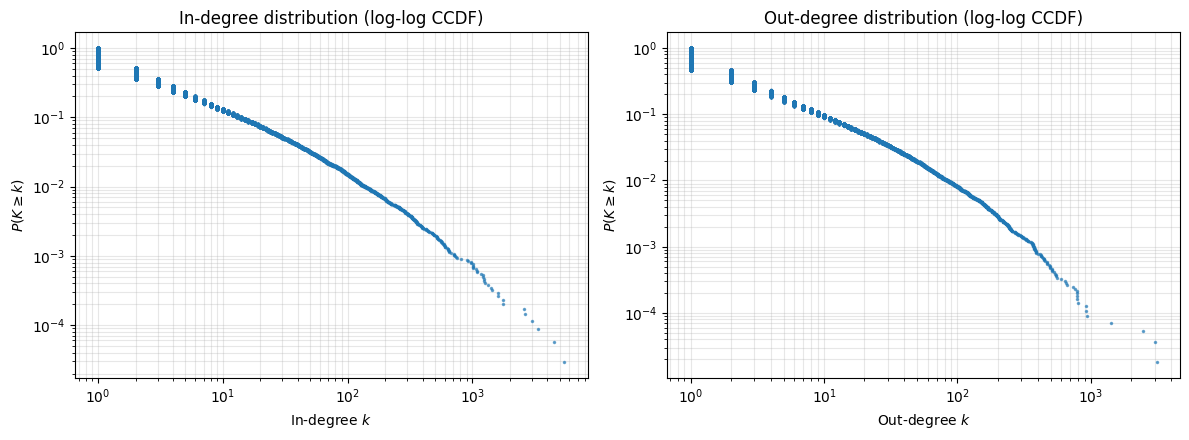

Saved degree distribution plot


In [27]:
in_degrees = np.array([d for _, d in G.in_degree()])
out_degrees = np.array([d for _, d in G.out_degree()])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# log-log CCDF for in-degree
for ax, degs, label in [(axes[0], in_degrees, "In-degree"), (axes[1], out_degrees, "Out-degree")]:
    degs_nonzero = degs[degs > 0]
    sorted_d = np.sort(degs_nonzero)
    ccdf = 1 - np.arange(len(sorted_d)) / len(sorted_d)
    ax.loglog(sorted_d, ccdf, marker=".", linestyle="none", markersize=3, alpha=0.6)
    ax.set_xlabel(f"{label} $k$")
    ax.set_ylabel(r"$P(K \geq k)$")
    ax.set_title(f"{label} distribution (log-log CCDF)")
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved degree distribution plot")